# W10-S01 — Práctica integrada y preparación para EC2

**Asignatura:** IMT-342 Robótica  
**Gestión:** II-2026  
**Docente:** M.Sc. Ing. Bernardo Quiroga Turdera  

**Integrantes:**  
- Roberth Williams Ruiz Condori  
- Mario Alberto Nina Gallo  

**Fuentes oficiales:** `w10_s01_practica.pdf` y `w10_s01_practica_asincrona_ec2.pdf` (Semana 10, Sesión 1).

## Herramientas de cálculo

Se emplean NumPy y Matplotlib para comprobar los resultados numéricos y representar las trayectorias.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)

def lspb(qi: float, qf: float, tf: float, a_mag: float):
    """Perfil LSPB simétrico en reposo, con aceleración de magnitud positiva.

    Devuelve tiempo de mezcla, velocidad de crucero y una función que evalúa
    posición, velocidad y aceleración para t dentro de [0, tf].
    """
    if tf <= 0 or a_mag <= 0:
        raise ValueError("tf y |a| deben ser positivos")
    delta = qf - qi
    if np.isclose(delta, 0):
        raise ValueError("El desplazamiento solicitado es nulo")
    a_min = 4*abs(delta)/tf**2
    if a_mag < a_min - 1e-12:
        raise ValueError(f"Perfil no factible; mínimo {a_min:.8g} rad/s²")
    acc = np.sign(delta)*a_mag
    discriminant = tf**2 - 4*abs(delta)/a_mag
    tc = (tf - np.sqrt(max(0.0, discriminant)))/2
    vc = acc*tc
    def evaluar(t):
        t = np.asarray(t, dtype=float)
        if np.any((t < 0) | (t > tf)):
            raise ValueError("tiempo fuera de [0, tf]")
        q = np.where(t <= tc,
                     qi + 0.5*acc*t**2,
                     np.where(t < tf-tc,
                              qi + vc*(t-0.5*tc),
                              qf - 0.5*acc*(tf-t)**2))
        v = np.where(t <= tc, acc*t,
                     np.where(t < tf-tc, vc, acc*(tf-t)))
        # En las fronteras se toma la aceleración por la derecha, excepto en t=tf.
        a = np.where(t < tc, acc, np.where(t < tf-tc, 0.0, -acc))
        return q, v, a
    return a_min, tc, vc, evaluar

# Parte I — Práctica integrada de la Unidad II

Fuente: `w10_s01_practica.pdf` (dos páginas).

## Ejercicio 1 — Cinemática inversa — método de Pieper

### Enunciado

Para un manipulador 6R genérico con muñeca esférica se conoce $\mathbf p_{6,d}^{0}=[2,1,1]^T$, $\mathbf z_{6,d}^{0}=[0,0,1]^T$ y $d_6=0.5$.

A. Calcular el centro de la muñeca.  
B. Plantear una expresión candidata para $q_1$ en el plano XY.  
C. Si $\cos q_3=0$, determinar las ramas principales mediante `atan2` e interpretarlas.  
D. Indicar la matriz necesaria para resolver la orientación de la muñeca.  
E. Establecer la verificación mediante cinemática directa.

### Desarrollo

**A. Centro de muñeca.** Se resta el desplazamiento desde el centro de la muñeca hasta el efector, en el eje final deseado:

$$^0\mathbf p_W=\, ^0\mathbf p_{6,d}-d_6\, ^0\mathbf z_{6,d}=
\begin{bmatrix}2\\1\\1\end{bmatrix}-0.5\begin{bmatrix}0\\0\\1\end{bmatrix}=
\begin{bmatrix}2\\1\\0.5\end{bmatrix}.$$

**B. Base:** usando la proyección XY y la hipótesis estándar dada, $q_1=\operatorname{atan2}(y_W,x_W)=\operatorname{atan2}(1,2)\approx0.463648\,\mathrm{rad}$ ($26.5651^\circ$). Es una **candidata** de orientación de base, sujeta a la geometría concreta del manipulador.

**C. Ramas del codo:** $c_3=\cos q_3=0$ y $s_3^2+c_3^2=1$. Entonces $s_3=\pm1$, de donde

$$\boxed{q_3^{(1)}=\operatorname{atan2}(1,0)=\pi/2},\quad
\boxed{q_3^{(2)}=\operatorname{atan2}(-1,0)=-\pi/2}.$$

Las dos soluciones representan **ramas geométricas** del brazo (asociables a codo arriba/abajo según el montaje), no errores de signo que deban descartarse automáticamente.

**D. Desacoplamiento de orientación:** tras calcular $(q_1,q_2,q_3)$, se necesita $^0R_3$ obtenido por FK del brazo. Para la muñeca:

$$\boxed{^3R_{6,d}=(^0R_3)^T\, ^0R_{6,d}}.$$

**E. Validación:** para cada solución articular candidata $\mathbf q^{(k)}$, evaluar la FK y comprobar toda la pose objetivo:

$$\boxed{^0T_6(\mathbf q^{(k)})\approx {}^0T_{6,d}}.$$

Esto exige comprobar traslación y orientación, no solo la distancia al centro de muñeca. Dado que no se especifican todos los parámetros geométricos ni la matriz de orientación objetivo, el planteamiento se mantiene en las expresiones analíticas solicitadas.

In [2]:
pd = np.array([2., 1., 1.])
zd = np.array([0., 0., 1.])
pw = pd - 0.5*zd
q1 = np.arctan2(pw[1], pw[0])
q3_ramas = np.array([np.arctan2(1, 0), np.arctan2(-1, 0)])
assert np.allclose(pw, [2, 1, .5])
assert np.allclose(q3_ramas, [np.pi/2, -np.pi/2])
print("pW =", pw, "; q1 =", q1, "rad =", np.degrees(q1), "grados")
print("Ramas q3 =", q3_ramas, "rad")

pW = [2.  1.  0.5] ; q1 = 0.4636476090008061 rad = 26.56505117707799 grados
Ramas q3 = [ 1.570796 -1.570796] rad


## Ejercicio 2 — Jacobiano geométrico y singularidades

### Enunciado

Para un brazo planar 2R, $a_1=a_2=1$, $q_1=0$, $q_2=\pi/2$. Se conocen $\mathbf o_0=[0,0,0]^T$, $\mathbf o_1=[1,0,0]^T$, $\mathbf o_2=[1,1,0]^T$ y $\mathbf z_0=\mathbf z_1=[0,0,1]^T$.

A. Construir las dos columnas y el Jacobiano geométrico.  
B. Calcular e interpretar la velocidad del efector para $\dot{\mathbf q}=[1,-1]^T$ rad/s.  
C. Analizar $J_p=\begin{bmatrix}0&0\\2&1\end{bmatrix}$ en la postura estirada: rango, singularidad y dirección perdida.  
D. Explicar por qué el determinante no es una descripción física suficiente de la singularidad.

### Desarrollo

**A. Columnas del Jacobiano.** Ambas juntas son revolutas:

$$\begin{aligned}
\mathbf o_2-\mathbf o_0&=[1,1,0]^T,&\mathbf z_0\times(\mathbf o_2-\mathbf o_0)&=[-1,1,0]^T,\\
\mathbf o_2-\mathbf o_1&=[0,1,0]^T,&\mathbf z_1\times(\mathbf o_2-\mathbf o_1)&=[-1,0,0]^T.
\end{aligned}$$

Por tanto,

$$J_1=\begin{bmatrix}-1\\1\\0\\0\\0\\1\end{bmatrix},\quad
J_2=\begin{bmatrix}-1\\0\\0\\0\\0\\1\end{bmatrix},\quad
J=\begin{bmatrix}-1&-1\\1&0\\0&0\\0&0\\0&0\\1&1\end{bmatrix}.$$

**B. Twist:** $\dot{\mathbf q}=[1,-1]^T$ rad/s,

$$\mathbf v_e=J\dot{\mathbf q}=
\begin{bmatrix}-1&-1\\1&0\\0&0\\0&0\\0&0\\1&1\end{bmatrix}
\begin{bmatrix}1\\-1\end{bmatrix}=
\begin{bmatrix}0\\1\\0\\0\\0\\0\end{bmatrix}.$$

La velocidad lineal del efector es $[0,1,0]^T$ m/s y la angular $[0,0,0]^T$ rad/s. Las contribuciones angulares se anulan y queda una **traslación instantánea en $+y$**.

**C. Brazo totalmente extendido:** $J_p=\begin{bmatrix}0&0\\2&1\end{bmatrix}$. Como las columnas son proporcionales, $\operatorname{rank}(J_p)=1<2$. Es una singularidad **para la tarea planar de posición 2D**: el movimiento cartesiano radial instantáneo en $x$ se pierde, aunque persiste la velocidad en $y$.

**D. ¿Por qué no basta el determinante?** El determinante se aplica a matrices cuadradas y solo certifica una degeneración algebraica. El criterio general es la **pérdida de rango** respecto de la movilidad esperada y su significado físico: una dirección de velocidad cartesiana deja de ser controlable instantáneamente. Aquí el Jacobiano geométrico completo es $6\times2$, por lo que no corresponde hablar de $\det J$.

In [3]:
o0=np.array([0.,0.,0.]); o1=np.array([1.,0.,0.]); o2=np.array([1.,1.,0.])
z=np.array([0.,0.,1.])
J1=np.r_[np.cross(z,o2-o0),z]
J2=np.r_[np.cross(z,o2-o1),z]
J=np.column_stack((J1,J2)); qdot=np.array([1.,-1.]); ve=J@qdot
Jp_sing=np.array([[0.,0.],[2.,1.]])
assert np.array_equal(ve, [0,1,0,0,0,0])
assert np.linalg.matrix_rank(Jp_sing)==1
print("Jacobiano geométrico:\n",J,"\nTwist =",ve)
print("Rango de Jp extendido =",np.linalg.matrix_rank(Jp_sing))

Jacobiano geométrico:
 [[-1. -1.]
 [ 1.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 1.  1.]] 
Twist = [0. 1. 0. 0. 0. 0.]
Rango de Jp extendido = 1


## Ejercicio 3 — Generación de trayectoria LSPB

### Enunciado

Una articulación debe desplazarse de $q_i=0$ a $q_f=2$ rad en $t_f=3$ s, con velocidad inicial y final nulas y aceleración simétrica de magnitud $1$ rad/s².

A. Calcular la aceleración mínima factible.  
B. Determinar el tiempo de mezcla $t_c$.  
C. Calcular la velocidad de crucero.  
D. Escribir $q(t)$, $\dot q(t)$ y $\ddot q(t)$ por tramos.  
E. Evaluar las tres magnitudes en $t=2.5$ s.

### Desarrollo

**A. Aceleración mínima** para un perfil simétrico no invertido: $a_{\min}=4|q_f-q_i|/t_f^2=8/9\approx0.888889\,\mathrm{rad/s^2}$. Como $1\ge8/9$, la trayectoria es factible.

**B. Tiempo de mezcla.** El área bajo el perfil trapezoidal de velocidad da $\Delta q=a\,t_c(t_f-t_c)$. Así,

$$t_c^2-t_ft_c+\frac{|\Delta q|}{a}=0,\qquad
\boxed{t_c=\frac{t_f-\sqrt{t_f^2-4|\Delta q|/a}}{2}}=\frac{3-\sqrt{9-8}}{2}=1\,\mathrm{s}.$$

Se elige la raíz menor para respetar $0<t_c\le t_f/2$; la otra raíz no corresponde al intervalo de aceleración.

**C. Velocidad de crucero:** $\dot q_c=a t_c=\boxed{1\,\mathrm{rad/s}}$.

**D. Funciones por fases** (unidades SI):

$$q(t)=\begin{cases}
\tfrac12t^2&0\le t\le1\\
t-\tfrac12&1<t\le2\\
2-\tfrac12(3-t)^2&2<t\le3
\end{cases}$$

$$\dot q(t)=\begin{cases}
t&0\le t\le1\\
1&1<t\le2\\
3-t&2<t\le3
\end{cases}$$

$$\ddot q(t)=\begin{cases}
+1&0<t<1\\
0&1<t<2\\
-1&2<t<3.
\end{cases}$$

La aceleración ideal tiene salto en $t=1$ y $t=2$ y no existe una derivada clásica única exactamente en esas fronteras. Posición y velocidad sí permanecen continuas.

**E. En $t=2.5\,\mathrm{s}$**, tercera fase:

$$q=2-\tfrac12(3-2.5)^2=\boxed{1.875\,\mathrm{rad}},\quad
\dot q=3-2.5=\boxed{0.5\,\mathrm{rad/s}},\quad
\ddot q=\boxed{-1\,\mathrm{rad/s^2}}.$$

In [4]:
a_min_I, tc_I, vc_I, fun_I = lspb(0,2,3,1)
q25, v25, a25 = (float(x) for x in fun_I(2.5))
assert np.isclose(a_min_I,8/9)
assert np.isclose(tc_I,1)
assert np.allclose([q25,v25,a25],[1.875,.5,-1])
q0,v0,_=fun_I(0.); qf,vf,_=fun_I(3.)
assert np.allclose([q0,v0,qf,vf],[0,0,2,0])
print("a_min =",a_min_I,"; tc =",tc_I,"; vc =",vc_I)
print("t=2.5: q, qdot, qddot =",q25,v25,a25)

a_min = 0.8888888888888888 ; tc = 1.0 ; vc = 1.0
t=2.5: q, qdot, qddot = 1.875 0.5 -1.0


**Representación gráfica de la trayectoria:** la posición es parabólica–lineal–parabólica, la velocidad es trapezoidal y la aceleración es constante por tramos.

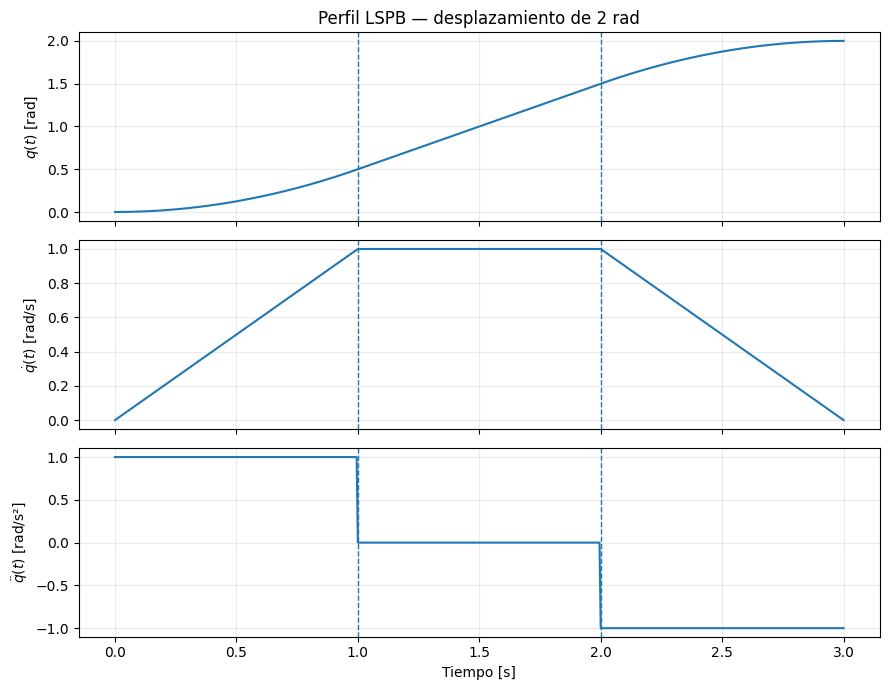

In [5]:
t = np.linspace(0.0, 3.0, 601)
q_t, qdot_t, qddot_t = fun_I(t)
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, valores, etiqueta in zip(
    axes,
    (q_t, qdot_t, qddot_t),
    (r"$q(t)$ [rad]", r"$\dot{q}(t)$ [rad/s]", r"$\ddot{q}(t)$ [rad/s²]")
):
    ax.plot(t, valores)
    ax.axvline(tc_I, linestyle="--", linewidth=1)
    ax.axvline(3.0 - tc_I, linestyle="--", linewidth=1)
    ax.set_ylabel(etiqueta)
    ax.grid(alpha=0.25)
axes[0].set_title("Perfil LSPB — desplazamiento de 2 rad")
axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

## Ejercicio 4 — Dinámica de Euler–Lagrange y torque

### Enunciado

Para un modelo 1R con ángulo desde la vertical inferior, $J=I_c+m\ell_c^2$, $T=\tfrac12J\dot q^2$ y $V=mg\ell_c(1-\cos q)$.

A. Formular el Lagrangiano.  
B. Obtener las derivadas de Euler–Lagrange.  
C. Deducir la ecuación dinámica e identificar sus componentes.  
D. Calcular el torque usando el estado de la tarea 3 en $t=2.5$ s con $J=0.25$ kg·m², $m=1$ kg, $\ell_c=0.5$ m y $g=9.81$ m/s². Interpretar el signo inercial.

### Desarrollo

**Modelo del docente, ángulo medido desde la vertical inferior:** $J=I_c+m\ell_c^2$ constante, $T=\tfrac12J\dot q^2$, $V=mg\ell_c(1-\cos q)$.

**A. Lagrangiano:**
$$\boxed{L(q,\dot q)=\tfrac12J\dot q^2-mg\ell_c(1-\cos q)}.$$

**B. Derivadas:**
$$\frac{\partial L}{\partial\dot q}=J\dot q,\qquad
\frac{d}{dt}\left(\frac{\partial L}{\partial\dot q}\right)=J\ddot q,\qquad
\frac{\partial L}{\partial q}=-mg\ell_c\sin q.$$

**C. Euler–Lagrange con torque generalizado $\tau$:**

$$\tau=\frac{d}{dt}\frac{\partial L}{\partial\dot q}-\frac{\partial L}{\partial q}
=\boxed{J\ddot q+mg\ell_c\sin q}.$$

$J\ddot q$ representa el **torque inercial** y $mg\ell_c\sin q$ el **torque gravitatorio**. En este modelo 1R con $J$ constante no hay un término independiente de Coriolis/centrífugo.

**D. Estado de I.3:** $q=1.875$, $\dot q=0.5$, $\ddot q=-1$. Dados $J=0.25\,\mathrm{kg\,m^2}$, $m=1\,\mathrm{kg}$, $\ell_c=0.5\,\mathrm m$ y $g=9.81\,\mathrm{m/s^2}$:

$$\tau_I=0.25(-1)=-0.25\,\mathrm{N\,m},\qquad
\tau_g=(1)(9.81)(0.5)\sin(1.875)=4.905\sin(1.875),$$

$$\boxed{\tau=-0.25+4.905\sin(1.875)\ \mathrm{N\,m}\approx4.43\ \mathrm{N\,m}}.$$

El torque inercial es negativo porque la aceleración angular va en sentido opuesto al movimiento positivo; la componente gravitatoria positiva es mayor.

In [6]:
Ji=.25; mI=1.; lcI=.5; g=9.81
tau_I_in=Ji*a25
tau_I_g=mI*g*lcI*np.sin(q25)
tau_I=tau_I_in+tau_I_g
print(f"tau_inercial={tau_I_in:.6f} N*m; tau_gravedad={tau_I_g:.6f} N*m; tau_total={tau_I:.6f} N*m")
assert np.isclose(tau_I_in,-.25)
assert 4.4 < tau_I < 4.5

tau_inercial=-0.250000 N*m; tau_gravedad=4.679791 N*m; tau_total=4.429791 N*m


## Ejercicio 5 — Integración de herramientas de robótica

### Enunciado

Construir la secuencia lógica que conecta Pieper, verificación por FK, perfiles LSPB, Jacobiano, rango/singularidad y dinámica Euler–Lagrange para ejecutar una tarea con un manipulador industrial 6R.

### Desarrollo

**Flujo conceptual de una tarea industrial 6R:**

```text
Pose deseada T_d ──► IK analítica (Pieper) ──► candidatos q_f^(k)
                                          │
                                          ▼
                             verificación por FK T(q_f^(k)) ≈ T_d
                                          │
                               escoger rama válida y segura
                                          │
                        q_i, q_f, t_f ──► LSPB ──► q(t), qdot(t), qddot(t)
                                                        │
                            ┌───────────────────────────┴──────────────────┐
                            ▼                                              ▼
                      J(q) qdot                                   Euler–Lagrange
                      velocidad TCP                                  torque τ(t)
                            │
                            ▼
                 rango de J(q) / singularidad
                 movilidad instantánea disponible
```

*Pieper* responde qué $q$ puede alcanzar la pose; *FK* comprueba la solución; *LSPB* parametriza el desplazamiento en tiempo; *Jacobiano* relaciona velocidades; *rango* comprueba direcciones instantáneas; *Lagrange–Euler* estima el torque para seguir la trayectoria. En una aplicación real habría que verificar límites, colisiones y condiciones de seguridad además de estos cálculos.

# Parte II — Práctica asíncrona de preparación EC2

Fuente: `w10_s01_practica_asincrona_ec2.pdf` (ejercicios 1 a 13).

## Ejercicio 1 — Selección de método

### Enunciado

Elegir entre Pieper, FK, Jacobiano, rango/singularidad, LSPB y Lagrange–Euler para: a) pose objetivo a articulaciones; b) velocidad del efector; c) pérdida de movilidad; d) movimiento continuo; e) torque; f) validación de una solución de IK.

### Desarrollo

| Pregunta de ingeniería | Herramienta principal | Por qué |
|---|---|---|
| a) Pose objetivo $T_d\mapsto$ articulaciones | **IK analítica (Pieper)** | Determina $\mathbf q$ |
| b) $\mathbf q,\dot{\mathbf q}\mapsto$ velocidad TCP | **Jacobiano** | $\mathbf v_e=J(\mathbf q)\dot{\mathbf q}$ |
| c) Detección de pérdida de movilidad | **Rango / singularidad** | Verifica independencia de columnas/direcciones |
| d) Movimiento entre estados articulares | **LSPB** | Genera $q(t),\dot q(t),\ddot q(t)$ |
| e) Posición, velocidad y aceleración a torque | **Lagrange–Euler** | Ecuación dinámica de movimiento |
| f) Comprobar una solución IK | **FK** | Evalúa $T(\mathbf q)$ frente a $T_d$ |

## Ejercicio 2 — Pieper — centro de muñeca

### Enunciado

Dados $\mathbf p_{6,d}=[1.8,0.6,1.2]^T$ m, $\mathbf z_{6,d}=[0,0,1]^T$ y $d_6=0.20$ m, hallar $\mathbf p_W$ e interpretar físicamente el resultado.

### Desarrollo

$$\mathbf p_W=\mathbf p_{6,d}-d_6\mathbf z_{6,d}
=\begin{bmatrix}1.8\\0.6\\1.2\end{bmatrix}
-0.20\begin{bmatrix}0\\0\\1\end{bmatrix}
=\begin{bmatrix}1.8\\0.6\\1.0\end{bmatrix}\ \mathrm m.$$

Es el punto de intersección geométrica ideal de los ejes de la muñeca esférica, utilizado para separar la IK de **posición** (primeras tres juntas) de la IK de **orientación** (últimas tres).

In [7]:
pw_II=np.array([1.8,.6,1.2])-.20*np.array([0.,0.,1.])
assert np.allclose(pw_II,[1.8,.6,1.])
print("pW =",pw_II,"m")

pW = [1.8 0.6 1. ] m


## Ejercicio 3 — Pieper — ramas y función atan2

### Enunciado

Si $c_3=\cos q_3=-\sqrt{2}/2$, hallar: a) ambos valores de $s_3$; b) las dos soluciones $q_3=\operatorname{atan2}(s_3,c_3)$; c) el significado geométrico de las ramas.

### Desarrollo

Se da $c_3=\cos q_3=-\sqrt 2/2$. Usamos identidad trigonométrica:

$$s_3=\pm\sqrt{1-c_3^2}=\pm\sqrt{1-\tfrac12}=\boxed{\pm\tfrac{\sqrt2}{2}}.$$

`atan2(seno, coseno)` recupera el cuadrante usando **ambos signos**. Si $s_3>0,c_3<0$, el ángulo está en el II cuadrante; si $s_3<0,c_3<0$, en el III (representado en $(-\pi,\pi]$ como ángulo negativo):

$$\boxed{q_3^{(1)}=\operatorname{atan2}(+\sqrt2/2,-\sqrt2/2)=3\pi/4},$$
$$\boxed{q_3^{(2)}=\operatorname{atan2}(-\sqrt2/2,-\sqrt2/2)=-3\pi/4}.$$

Las dos ramas producen el mismo coseno pero senos opuestos: describen **configuraciones geométricas alternativas** que deberán pasar por el control de límites y la FK de validación.

In [8]:
c3=-np.sqrt(2)/2
s3=np.array([np.sqrt(1-c3**2),-np.sqrt(1-c3**2)])
q3_II=np.arctan2(s3,c3)
assert np.allclose(q3_II,[3*np.pi/4,-3*np.pi/4])
print("s3 =",s3,"; q3 =",q3_II,"rad =",np.degrees(q3_II),"grados")

s3 = [ 0.707107 -0.707107] ; q3 = [ 2.356194 -2.356194] rad = [ 135. -135.] grados


## Ejercicio 4 — Pieper — orden lógico

### Enunciado

Ordenar desde la pose deseada hasta la validación FK los pasos de resolución de Pieper, incluido el centro de muñeca y la orientación residual. Escribir $R_{36}=(R_{03})^TR_{06,d}$.

### Desarrollo

1. Partir de la pose objetivo $^0T_{6,d}$ (contiene posición y orientación).
2. Calcular el centro de muñeca $^0\mathbf p_W$.
3. Resolver la IK de posición $q_1,q_2,q_3$; conservar las ramas válidas.
4. Calcular la orientación residual $^3R_{6,d}$.
5. Resolver $q_4,q_5,q_6$ para cada rama compatible.
6. Verificar cada $\mathbf q^{(k)}$ mediante FK: $^0T_6(\mathbf q^{(k)})\approx{}^0T_{6,d}$.

Para el paso 4, partimos de $^0R_{6,d}={}^0R_3\,{}^3R_{6,d}$; multiplicamos a la izquierda por $(^0R_3)^T$ porque la rotación es ortogonal:

$$\boxed{{}^3R_{6,d}=({}^0R_3)^T{}^0R_{6,d}}.$$

No se debe confundir la **IK del robot** con la operación $T^{-1}$ de un cambio de marco.

## Ejercicio 5 — Jacobiano — columna de una junta revoluta

### Enunciado

Se conocen $\mathbf z_{i-1}=[0,0,1]^T$, $\mathbf o_{i-1}=[1,1,0]^T$ y $\mathbf o_n=[3,2,0]^T$. Calcular $J_i=[(\mathbf z_{i-1}\times(\mathbf o_n-\mathbf o_{i-1}))^T,\mathbf z_{i-1}^T]^T$ e interpretar su significado físico.

### Desarrollo

Primero, radio desde la articulación hasta el efector:

$$\mathbf r=\mathbf o_n-\mathbf o_{i-1}=\begin{bmatrix}2\\1\\0\end{bmatrix}.$$

Producto cruz con $\mathbf z=[0,0,1]^T$:

$$\mathbf z\times\mathbf r=
\begin{vmatrix}\mathbf i&\mathbf j&\mathbf k\\0&0&1\\2&1&0\end{vmatrix}
=\begin{bmatrix}0\cdot0-1\cdot1\\1\cdot2-0\cdot0\\0\cdot1-0\cdot2\end{bmatrix}
=\begin{bmatrix}-1\\2\\0\end{bmatrix}.$$

Luego,

$$J_i=\begin{bmatrix}-1\\2\\0\\0\\0\\1\end{bmatrix}.$$

Significa que una velocidad unitaria positiva de esa junta revoluta produce $\mathbf v_L=[-1,2,0]^T$ m/s y $\boldsymbol\omega=[0,0,1]^T$ rad/s sobre el efector, considerando las demás articulaciones fijas.

In [9]:
z5=np.array([0.,0.,1.]); r5=np.array([3.,2.,0.])-np.array([1.,1.,0.])
Jcol=np.r_[np.cross(z5,r5),z5]
assert np.array_equal(Jcol,[-1,2,0,0,0,1])
print("Radio =",r5,"; columna J_i =",Jcol)

Radio = [2. 1. 0.] ; columna J_i = [-1.  2.  0.  0.  0.  1.]


## Ejercicio 6 — Jacobiano — velocidad del efector

### Enunciado

Dado $J=\begin{bmatrix}-1&-1\\1&0\\0&0\\0&0\\0&0\\1&1\end{bmatrix}$ y $\dot{\mathbf q}=[2,-1]^T$ rad/s, calcular el twist $\mathbf v_e=J\dot{\mathbf q}$ y separar velocidad lineal y angular.

### Desarrollo

Dado

$$J=\begin{bmatrix}-1&-1\\1&0\\0&0\\0&0\\0&0\\1&1\end{bmatrix},
\qquad\dot{\mathbf q}=\begin{bmatrix}2\\-1\end{bmatrix}\,\mathrm{rad/s},$$

la multiplicación fila por columna es

$$\mathbf v_e=J\dot{\mathbf q}=
\begin{bmatrix}-2+1\\2+0\\0\\0\\0\\2-1\end{bmatrix}
=\begin{bmatrix}-1\\2\\0\\0\\0\\1\end{bmatrix}.$$

Lectura física: velocidad **lineal** $\mathbf v_L=[-1,2,0]^T$ m/s (plano XY) y velocidad **angular** $\boldsymbol\omega=[0,0,1]^T$ rad/s alrededor de $+z$.

In [10]:
ve_II=J@np.array([2.,-1.])
assert np.array_equal(ve_II,[-1,2,0,0,0,1])
print("Twist II.6 =",ve_II)

Twist II.6 = [-1.  2.  0.  0.  0.  1.]


## Ejercicio 7 — Singularidad — rango

### Enunciado

Para $J_p=\begin{bmatrix}0&0\\3&1\end{bmatrix}$, determinar: a) rango; b) estado regular/singular en una tarea planar 2D; c) interpretación física; d) límites de usar «$\det J=0$» como única explicación.

### Desarrollo

$$J_p=\begin{bmatrix}0&0\\3&1\end{bmatrix}.$$

Las dos columnas $[0,3]^T$ y $[0,1]^T$ son linealmente dependientes, pues la primera es 3 veces la segunda:

$$\boxed{\operatorname{rank}(J_p)=1<2}.$$

Para una tarea de **posición planar 2D**, la configuración es singular: $\dot x=0$ independientemente de las velocidades de las juntas, y $\dot y=3\dot q_1+\dot q_2$. Así, se pierde movilidad instantánea independiente en **$x$**, no todo movimiento. El determinante nulo sería un diagnóstico algebraico válido por ser $2\times2$, pero no explica por sí mismo **cuál dirección física** se ha perdido, ni se generaliza a Jacobianos no cuadrados.

In [11]:
Jp7=np.array([[0.,0.],[3.,1.]])
assert np.linalg.matrix_rank(Jp7)==1
print("rank(Jp) =",np.linalg.matrix_rank(Jp7),"; det(Jp) =",np.linalg.det(Jp7))

rank(Jp) = 1 ; det(Jp) = 0.0


## Ejercicio 8 — Singularidades del manipulador 2R

### Enunciado

Partiendo de $\det J_p=a_1a_2\sin q_2$ con $a_1a_2\ne0$, hallar las configuraciones singulares, interpretarlas geométricamente y explicar el comportamiento de la IK diferencial en su proximidad.

### Desarrollo

Con longitudes $a_1a_2\neq0$ y $\det J_p=a_1a_2\sin q_2$:

$$\det J_p=0\iff\sin q_2=0\iff\boxed{q_2=k\pi,\quad k\in\mathbb Z}.$$

Configuraciones principales $q_2=0$ y $q_2=\pi$ (módulo $2\pi$): eslabones colineales, extendidos o replegados, de forma que las dos columnas translacionales del Jacobiano dejan de proporcionar direcciones independientes.

En la **cinemática inversa diferencial**, imponer ciertas velocidades del efector cuando se está muy cerca de singularidad puede exigir velocidades articulares enormes (mal condicionamiento). La pérdida es **local e instantánea**, no una inmovilidad global del robot.

In [12]:
for q2 in [0,np.pi,np.pi/2]:
    print(f"q2={q2:.5f} rad, sin(q2)={np.sin(q2):.6g} (0 => singular)")

q2=0.00000 rad, sin(q2)=0 (0 => singular)
q2=3.14159 rad, sin(q2)=1.22465e-16 (0 => singular)
q2=1.57080 rad, sin(q2)=1 (0 => singular)


## Ejercicio 9 — LSPB — construcción completa

### Enunciado

Con $q_i=0$, $q_f=1.5$ rad, $t_f=3$ s y $|\ddot q_c|=0.75$ rad/s², hallar: aceleración mínima, factibilidad, tiempo de mezcla, velocidad de crucero, perfiles por fases y estado en $t=1.5$ s.

### Desarrollo

1. **Mínimo:** $a_{\min}=4\Delta q/t_f^2=4(1.5)/9=\boxed{2/3\,\mathrm{rad/s^2}}$.
2. **Factibilidad:** $0.75>2/3$, por tanto sí es factible.
3. **Tiempo de mezcla:**
$$t_c=\frac{3-\sqrt{9-4(1.5)/0.75}}2=\frac{3-1}{2}=\boxed{1\,\mathrm s}.$$
4. **Crucero:** $\dot q_c=at_c=\boxed{0.75\,\mathrm{rad/s}}$.
5. **Perfiles por tramos**:

$$q(t)=\begin{cases}
0.375t^2&0\le t\le1\\
0.75(t-0.5)&1<t\le2\\
1.5-0.375(3-t)^2&2<t\le3
\end{cases}$$

$$\dot q(t)=\begin{cases}
0.75t&0\le t\le1\\
0.75&1<t\le2\\
0.75(3-t)&2<t\le3
\end{cases}$$

$$\ddot q(t)=\begin{cases}
+0.75&0<t<1\\
0&1<t<2\\
-0.75&2<t<3.
\end{cases}$$

6. **En $t=1.5\,\mathrm{s}$** (crucero):
$$q=0.75(1.5-0.5)=\boxed{0.75\,\mathrm{rad}},\quad
\dot q=\boxed{0.75\,\mathrm{rad/s}},\quad
\ddot q=\boxed{0\,\mathrm{rad/s^2}}.$$

El valor de $\ddot q$ en $t=1$ o $t=2$ requeriría convención lateral, igual que en I.3.

In [13]:
a_min_II,tc_II,vc_II,fun_II=lspb(0,1.5,3,.75)
q15,v15,a15=(float(v) for v in fun_II(1.5))
assert np.isclose(a_min_II,2/3)
assert np.isclose(tc_II,1)
assert np.allclose([q15,v15,a15],[.75,.75,0])
print("a_min =",a_min_II,"; tc =",tc_II,"; vc =",vc_II)
print("t=1.5 s: q =",q15,"; qdot =",v15,"; qddot =",a15)

a_min = 0.6666666666666666 ; tc = 1.0 ; vc = 0.75
t=1.5 s: q = 0.75 ; qdot = 0.75 ; qddot = 0.0


**Representación gráfica:** se muestran la posición, velocidad y aceleración correspondientes al perfil de $1.5$ rad.

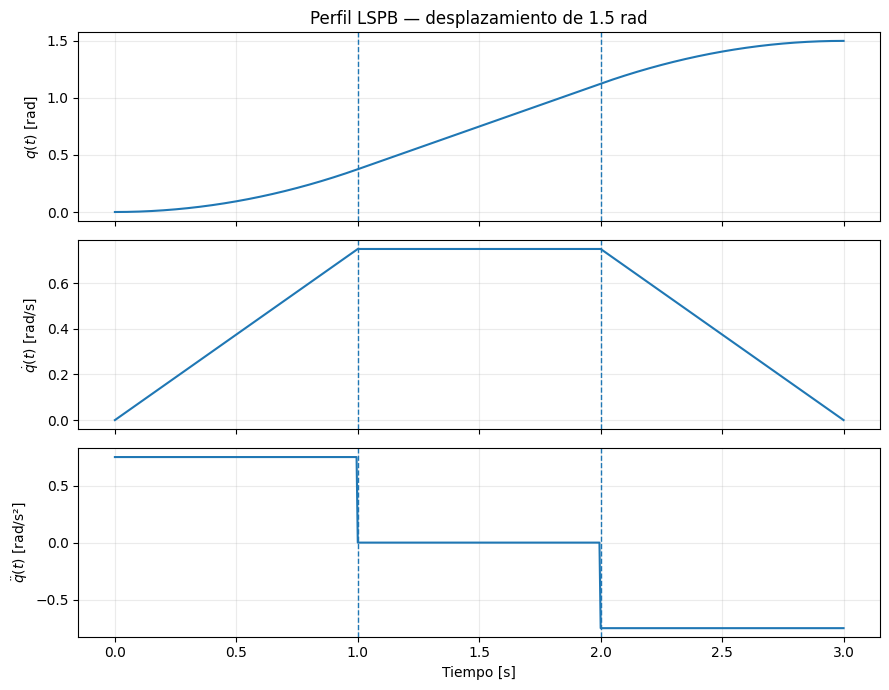

In [14]:
t = np.linspace(0.0, 3.0, 601)
q_t, qdot_t, qddot_t = fun_II(t)
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, valores, etiqueta in zip(
    axes,
    (q_t, qdot_t, qddot_t),
    (r"$q(t)$ [rad]", r"$\dot{q}(t)$ [rad/s]", r"$\ddot{q}(t)$ [rad/s²]")
):
    ax.plot(t, valores)
    ax.axvline(tc_II, linestyle="--", linewidth=1)
    ax.axvline(3.0 - tc_II, linestyle="--", linewidth=1)
    ax.set_ylabel(etiqueta)
    ax.grid(alpha=0.25)
axes[0].set_title("Perfil LSPB — desplazamiento de 1.5 rad")
axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

## Ejercicio 10 — LSPB — interpretación física

### Enunciado

Explicar la continuidad de $q(t)$ y $\dot q(t)$, la posibilidad de discontinuidades finitas de $\ddot q(t)$ en el modelo LSPB y por qué «trapezoidal» se refiere a la velocidad.

### Desarrollo

**a) Continuidad de $q(t)$:** las articulaciones no pueden saltar de un ángulo a otro sin recorrer el espacio intermedio. Un salto de posición implicaría velocidad impulsiva no realizable.

**b) Continuidad de $\dot q(t)$:** la velocidad no puede cambiar instantáneamente bajo aceleraciones finitas. Un salto de velocidad exigiría una aceleración impulsiva y, en el modelo de inercia, torques no acotados.

**c) Por qué $\ddot q(t)$ puede saltar:** en la idealización LSPB se permiten cambios instantáneos **finito a finito** de aceleración entre fases (el *jerk* sería impulsivo en las fronteras). Los accionamientos reales requieren suavizar esas transiciones cuando sea necesario.

**d) Qué es trapezoidal:** el área bajo $\dot q(t)$ representa desplazamiento, y su gráfico presenta rampa ascendente, meseta constante y rampa descendente. $q(t)$, en cambio, es parabólica–lineal–parabólica, **no trapezoidal**.

## Ejercicio 11 — Dinámica — derivación de Euler–Lagrange

### Enunciado

Desde $T=\tfrac12J\dot q^2$ y $V=mg\ell_c(1-\cos q)$, formular $L=T-V$, desarrollar las derivadas de Euler–Lagrange y deducir la ecuación del torque.

### Desarrollo

Energías del modelo docente 1R, con $J$ constante:

$$T=\tfrac12 J\dot q^2,\qquad V=mg\ell_c(1-\cos q).$$

El lagrangiano es
$$\boxed{L=T-V=\tfrac12 J\dot q^2-mg\ell_c(1-\cos q)}.$$

Aplicamos sucesivamente:

$$\frac{\partial L}{\partial\dot q}=J\dot q,\quad
\frac{d}{dt}\left(\frac{\partial L}{\partial\dot q}\right)=J\ddot q,\quad
\frac{\partial L}{\partial q}=-mg\ell_c\sin q.$$

Por Euler–Lagrange,

$$\tau=\frac{d}{dt}\left(\frac{\partial L}{\partial\dot q}\right)-\frac{\partial L}{\partial q}
=\boxed{\underbrace{J\ddot q}_{\mathrm{inercial}}+\underbrace{mg\ell_c\sin q}_{\mathrm{gravitacional}}}.$$

Si $q=0$ (vertical inferior) el torque gravitatorio se anula; su magnitud y signo dependen de la postura.

## Ejercicio 12 — Dinámica — torque numérico

### Enunciado

Con $J=0.30$ kg·m², $m=1.5$ kg, $\ell_c=0.4$ m, $g=9.81$ m/s², $q=\pi/3$, $\dot q=0.8$ rad/s y $\ddot q=-1.2$ rad/s², calcular torque inercial, gravitatorio y total. Explicar por qué no figura $\dot q$ en esta ecuación 1R.

### Desarrollo

$$\tau=J\ddot q+mg\ell_c\sin q.$$

Componente inercial:
$$\boxed{\tau_I=(0.30)(-1.2)=-0.36\,\mathrm{N\,m}}.$$

Componente gravitatoria:
$$\tau_g=(1.5)(9.81)(0.4)\sin(\pi/3)=5.886\cdot\frac{\sqrt3}2
=\boxed{5.09743\ldots\,\mathrm{N\,m}}.$$

Total:
$$\boxed{\tau\approx-0.36+5.09743=4.73743\,\mathrm{N\,m}\approx4.74\,\mathrm{N\,m}}.$$

$\dot q=0.8$ es un dato de estado útil en modelos más generales, pero no aparece de manera independiente en la ecuación **1R de inercia constante, sin fricción**, porque su energía cinética depende solo de $\dot q^2$ y la derivada temporal lleva a $J\ddot q$.

In [15]:
tauII_in=.30*(-1.2)
tauII_g=1.5*9.81*.4*np.sin(np.pi/3)
tauII=tauII_in+tauII_g
assert np.isclose(tauII_in,-.36)
assert np.isclose(tauII,4.73743,atol=3e-4)
print(f"tau_I={tauII_in:.6f}; tau_g={tauII_g:.6f}; tau_total={tauII:.6f} N*m")

tau_I=-0.360000; tau_g=5.097426; tau_total=4.737426 N*m


## Ejercicio 13 — Integración tipo EC2

### Enunciado

Para un robot que debe alcanzar $T_d$, escoger solución articular, moverse en tiempo finito, conocer la velocidad cartesiana, diagnosticar singularidades y estimar el torque, describir herramientas, entradas, salidas, validación y diagrama de flujo.

### Desarrollo

| Paso | Herramienta | Entrada | Salida | Comprobación / criterio |
|---|---|---|---|---|
| 1. Resolver pose | **Pieper** | $T_d$, geometría 6R | Conjunto $\{q_f^{(k)}\}$ | Ramas reales y límites articulares |
| 2. Confirmar pose | **FK** | Cada $q_f^{(k)}$ | $T(q_f^{(k)})$ | Comparación de posición y orientación con $T_d$ |
| 3. Generar movimiento | **LSPB** | $q_i,q_f,t_f,a$ | $q(t),\dot q(t),\ddot q(t)$ | Factibilidad, continuidad de $q,\dot q$, condiciones de borde |
| 4. Obtener velocidad TCP | **Jacobiano** | $q(t),\dot q(t)$ | $v_e(t)=J(q)\dot q$ | Unidades y marcos correctos |
| 5. Diagnosticar movilidad | **Rango de $J$** | $J(q(t))$ | Rango / singularidades | Comparar con el rango esperado; identificar dirección perdida |
| 6. Estimar esfuerzos | **Euler–Lagrange** | $q(t),\dot q(t),\ddot q(t)$ y parámetros físicos | $\tau(t)$ | Magnitud, signo y límites de accionamiento |

```text
T_d ─► IK/Pieper ─► {q_f^(k)} ─► FK: T(q_f^(k)) ≈ T_d ─► seleccionar q_f
                                                               │
                                                               ▼
                                               (q_i, q_f, t_f, a) ─► LSPB
                                                               │
                                                 q(t), qdot(t), qddot(t)
                                                               │
                                   ┌───────────────────────────┴──────────────┐
                                   ▼                                          ▼
                            J(q)·qdot → v_e                      Dinámica → tau(t)
                                   │
                            rank(J), singularidad
```

La verificación de la pose mediante FK ocurre **antes** de aceptar la solución de IK.

## Referencias

- B. Quiroga Turdera, *Hoja Práctica Integrada: Diagnóstico Unidad II*, Semana 10, Sesión 1 (`w10_s01_practica.pdf`).
- B. Quiroga Turdera, *Práctica Asíncrona de Preparación para EC2*, Semana 10, Sesión 1 (`w10_s01_practica_asincrona_ec2.pdf`).
- Material de corrección oficial: `w10_s01_practica_soluciones.pdf` y `w10_s01_practica_asincrona_ec2_soluciones.pdf`.